## **0. Necessary Imports**

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms, datasets
import copy

device = torch.device("mps") if torch.mps.is_available() else torch.device("cpu")

/opt/anaconda3/envs/ai/lib/python3.10/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/opt/anaconda3/envs/ai/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <0B7EB158-53DC-3403-8A49-22178CAB4612> /opt/anaconda3/envs/ai/lib/python3.10/site-packages/torchvision/image.so
  Reason: tried: '/opt/anaconda3/envs/ai/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/ai/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/ai/lib/python3.10/lib-dynload/../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/ai/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before

## **1. Defining Augmentations**

In [2]:
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomAffine(degrees=(10, 40), translate=(0.1, 0.2), scale=(0.85, 1.15)),
    transforms.RandomPerspective(distortion_scale=0.2),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

train_dataset = datasets.Flowers102(root='./data/', split='test', download=True, transform=train_transforms)
valid_dataset = datasets.Flowers102(root='./data/', split='val', download=True, transform=train_transforms)
test_dataset = datasets.Flowers102(root='./data/', split='train', download=True, transform=test_transforms)

full_train_dataset = train_dataset + valid_dataset
len(full_train_dataset), len(test_dataset)

(7169, 1020)

## **2. Creating Datasets and Dataloaders**

In [3]:
class GrayscaleToColorDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.transform = transforms.Grayscale(num_output_channels=1)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, _ = self.dataset[idx]
        grayscale_image = self.transform(image)
        return grayscale_image, image

train_percentage = 80
full_size = len(full_train_dataset)
train_size = int(full_size * (train_percentage / 100))

indices = list(range(0, full_size))
np.random.seed(67)
np.random.shuffle(indices)

train_indices = indices[:train_size]
valid_indices = indices[train_size:]

small_train_dataset = Subset(full_train_dataset, train_indices)
small_valid_dataset = Subset(full_train_dataset, valid_indices)

trainset = GrayscaleToColorDataset(small_train_dataset)
validset = GrayscaleToColorDataset(small_valid_dataset)
testset = GrayscaleToColorDataset(test_dataset)

batch_size = 16

trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
validloader = DataLoader(validset, batch_size=batch_size, shuffle=True)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False)

print(f"Train dataset size: {len(trainset)}")
print(f"Validation dataset size: {len(validset)}")
print(f"Test dataset size: {len(testset)}")

Train dataset size: 5735
Validation dataset size: 1434
Test dataset size: 1020


## **3.1 Visualize Training Data**

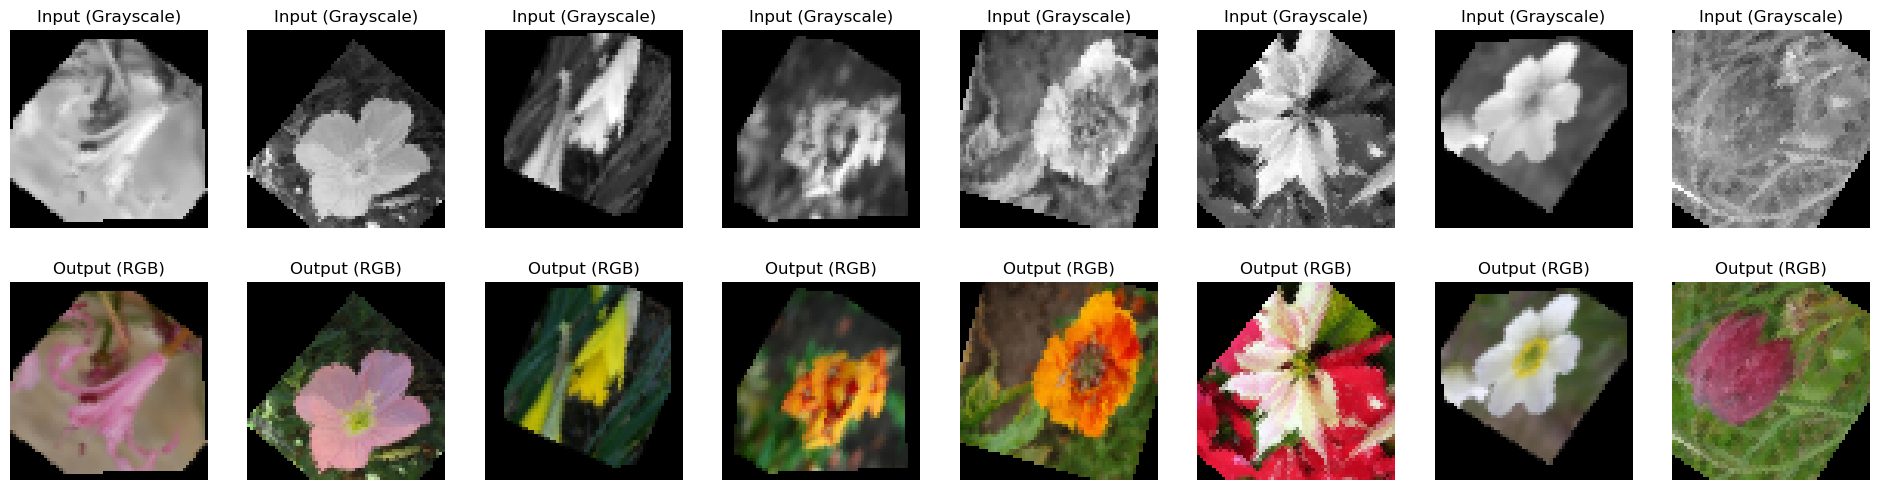

In [4]:
def visualize_batch(dataloader):
  inputs, targets = next(iter(dataloader))
  rows, cols = 2, 8
  figure = plt.figure(figsize=(3 * cols, 6))

  for i in range(cols):
      img_input = inputs[i].squeeze(0)
      img_input = img_input.numpy()
      figure.add_subplot(rows, cols, i + 1)
      plt.title('Input (Grayscale)')
      plt.axis('off')
      plt.imshow(img_input, cmap='gray')

      img_target = targets[i]
      img_target = np.transpose(img_target.numpy(), (1, 2, 0))
      figure.add_subplot(rows, cols, i + cols + 1)
      plt.title('Output (RGB)')
      plt.axis('off')
      plt.imshow(img_target)
  plt.show()

visualize_batch(trainloader)

## **3.2 Creating a CNN Model**

In [22]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding='same'),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding='same'),
            nn.BatchNorm2d(channels)
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = x
        out = self.block(x)
        out += residual
        return self.relu(out)

class ColorizationCNN(nn.Module):
    def __init__(self):
        super(ColorizationCNN, self).__init__()

        self.encoder1 = self._conv_maxpool_layer(1, 32)
        self.encoder2 = self._conv_maxpool_layer(32, 64)
        self.encoder3 = self._conv_maxpool_layer(64, 128)

        self.bottleneck = nn.Sequential(
            ResidualBlock(128),
            ResidualBlock(128),
            ResidualBlock(128)
        )

        self.decoder1 = self._transpose_conv_layer(128, 64)
        self.decoder2 = self._transpose_conv_layer(64, 32)
        self.decoder3 = self._transpose_conv_layer(32, 16)

        self.last_layer = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=3, kernel_size=3, stride=1, padding='same'),
            nn.Sigmoid()
        )

    def _conv_maxpool_layer(self, in_channels, out_channels, kernel_size=3, stride=1, padding='same'):
        return nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2)
        )
        
    def _transpose_conv_layer(self, in_channels, out_channels, kernel_size=3, stride=2, padding=1, output_padding=1):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=padding, output_padding=output_padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        out = self.encoder1(x)
        out = self.encoder2(out)
        out = self.encoder3(out)
        out = self.bottleneck(out)
        out = self.decoder1(out)
        out = self.decoder2(out)
        out = self.decoder3(out)
        out = self.last_layer(out)
        return out

## **3.3 Creating a FCN Model**

In [6]:
class ColorizationLinear(nn.Module):
    def __init__(self):
        super(ColorizationLinear, self).__init__()

        self.flatten = nn.Flatten()

        self.layer1 = self._linear_layer(64 * 64, 4096)
        self.layer2 = self._linear_layer(4096, 2048)
        self.layer3 = self._linear_layer(2048, 4096)
        self.last_layer = nn.Sequential(
            nn.Linear(4096, 3 * 64 * 64),
            nn.Sigmoid()
        )

        self.unflatten = nn.Unflatten(dim=1, unflattened_size=(3, 64, 64))

    def _linear_layer(self, in_features, out_features):
        return nn.Sequential(
            nn.Linear(in_features, out_features),
            nn.BatchNorm1d(out_features),
            nn.ReLU(),
            nn.Dropout(0.4)
        )

    def forward(self, x):
        out = self.flatten(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.last_layer(out)
        out = self.unflatten(out)
        return out

## **4.1 Plotting Model Parameter Count and Size**

In [23]:
model_cnn = ColorizationCNN().to(device)
summary(model_cnn, input_size=(16, 1, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
ColorizationCNN                          [16, 3, 64, 64]           --
├─Sequential: 1-1                        [16, 32, 32, 32]          --
│    └─Conv2d: 2-1                       [16, 32, 64, 64]          320
│    └─BatchNorm2d: 2-2                  [16, 32, 64, 64]          64
│    └─ReLU: 2-3                         [16, 32, 64, 64]          --
│    └─MaxPool2d: 2-4                    [16, 32, 32, 32]          --
├─Sequential: 1-2                        [16, 64, 16, 16]          --
│    └─Conv2d: 2-5                       [16, 64, 32, 32]          18,496
│    └─BatchNorm2d: 2-6                  [16, 64, 32, 32]          128
│    └─ReLU: 2-7                         [16, 64, 32, 32]          --
│    └─MaxPool2d: 2-8                    [16, 64, 16, 16]          --
├─Sequential: 1-3                        [16, 128, 8, 8]           --
│    └─Conv2d: 2-9                       [16, 128, 16, 16]         73,856
│    

In [16]:
model_fcn = ColorizationLinear().to(device)
summary(model_fcn, input_size = (16, 1, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
ColorizationLinear                       [16, 3, 64, 64]           --
├─Flatten: 1-1                           [16, 4096]                --
├─Sequential: 1-2                        [16, 4096]                --
│    └─Linear: 2-1                       [16, 4096]                16,781,312
│    └─BatchNorm1d: 2-2                  [16, 4096]                8,192
│    └─ReLU: 2-3                         [16, 4096]                --
│    └─Dropout: 2-4                      [16, 4096]                --
├─Sequential: 1-3                        [16, 2048]                --
│    └─Linear: 2-5                       [16, 2048]                8,390,656
│    └─BatchNorm1d: 2-6                  [16, 2048]                4,096
│    └─ReLU: 2-7                         [16, 2048]                --
│    └─Dropout: 2-8                      [16, 2048]                --
├─Sequential: 1-4                        [16, 4096]             

## **4.2 Defining Loss Function and Optimizer**

In [24]:
loss_fn = nn.L1Loss()
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=0.001)
optimizer_fcn = optim.Adam(model_fcn.parameters(), lr=0.001)

## **5. Training the Image Colorization Models**

In [ ]:
def training(model, loss_fn, optimizer, epochs=200, early_stop_patience=10):
    model = model.to(device)
    train_losses, valid_losses = [], []
    best_loss = float('inf')
    best_weights = copy.deepcopy(model.state_dict())
    early_stop_count = 0

    for epoch in range(1, epochs + 1):
        # Training
        model.train()
        train_loss = 0.0
        for X, Y in trainloader:
            X, Y = X.to(device), Y.to(device)
            optimizer.zero_grad()
            prediction = model(X)
            loss = loss_fn(prediction, Y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(trainloader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        valid_loss = 0.0
        with torch.no_grad():
            for X, Y in validloader:
                X, Y = X.to(device), Y.to(device)
                prediction = model(X)
                loss = loss_fn(prediction, Y)
                valid_loss += loss.item()

        valid_loss /= len(validloader)
        valid_losses.append(valid_loss)

        # Early stopping
        if valid_loss < best_loss:
            best_loss = valid_loss
            best_weights = copy.deepcopy(model.state_dict())
            early_stop_count = 0
        else:
            early_stop_count += 1
            if early_stop_count >= early_stop_patience:
                print(f'Epoch {epoch}/{epochs}: Train Loss = {train_loss:.4f}, Valid Loss = {valid_loss:.4f}')
                print('Early stopping triggered')
                break

        print(f'Epoch {epoch}/{epochs}: Train Loss = {train_loss:.4f}, Valid Loss = {valid_loss:.4f}')

    model.load_state_dict(best_weights)
    print('Training finished')
    return model, train_losses, valid_losses

In [28]:
best_model_cnn, train_losses_cnn, valid_losses_cnn = training(model_cnn, loss_fn, optimizer_cnn, epochs=200, early_stop_patience=10)
torch.save(best_model_cnn.state_dict(), 'best_model_cnn.pth')

Epoch 1/200: Train Loss = 0.1021, Valid Loss = 0.0873
Epoch 2/200: Train Loss = 0.0823, Valid Loss = 0.0774
Epoch 3/200: Train Loss = 0.0788, Valid Loss = 0.0773
Epoch 4/200: Train Loss = 0.0771, Valid Loss = 0.0748
Epoch 5/200: Train Loss = 0.0754, Valid Loss = 0.0772
Epoch 6/200: Train Loss = 0.0750, Valid Loss = 0.0739
Epoch 7/200: Train Loss = 0.0735, Valid Loss = 0.0722
Epoch 8/200: Train Loss = 0.0732, Valid Loss = 0.0709
Epoch 9/200: Train Loss = 0.0727, Valid Loss = 0.0703
Epoch 10/200: Train Loss = 0.0722, Valid Loss = 0.0711
Epoch 11/200: Train Loss = 0.0714, Valid Loss = 0.0716
Epoch 12/200: Train Loss = 0.0712, Valid Loss = 0.0696
Epoch 13/200: Train Loss = 0.0710, Valid Loss = 0.0697
Epoch 14/200: Train Loss = 0.0703, Valid Loss = 0.0705
Epoch 15/200: Train Loss = 0.0707, Valid Loss = 0.0697
Epoch 16/200: Train Loss = 0.0703, Valid Loss = 0.0699
Epoch 17/200: Train Loss = 0.0706, Valid Loss = 0.0703
Epoch 18/200: Train Loss = 0.0699, Valid Loss = 0.0683
Epoch 19/200: Train

In [30]:
best_model_fcn, train_losses_fcn, valid_losses_fcn = training(model_fcn, loss_fn, optimizer_fcn, epochs=200, early_stop_patience=10)
torch.save(best_model_fcn.state_dict(), 'best_model_fcn.pth')

Epoch 1/200: Train Loss = 0.1564, Valid Loss = 0.1380
Epoch 2/200: Train Loss = 0.1454, Valid Loss = 0.1345
Epoch 3/200: Train Loss = 0.1399, Valid Loss = 0.1283
Epoch 4/200: Train Loss = 0.1367, Valid Loss = 0.1277
Epoch 5/200: Train Loss = 0.1334, Valid Loss = 0.1234
Epoch 6/200: Train Loss = 0.1300, Valid Loss = 0.1191
Epoch 7/200: Train Loss = 0.1270, Valid Loss = 0.1179
Epoch 8/200: Train Loss = 0.1256, Valid Loss = 0.1160
Epoch 9/200: Train Loss = 0.1242, Valid Loss = 0.1160
Epoch 10/200: Train Loss = 0.1233, Valid Loss = 0.1137
Epoch 11/200: Train Loss = 0.1229, Valid Loss = 0.1132
Epoch 12/200: Train Loss = 0.1223, Valid Loss = 0.1146
Epoch 13/200: Train Loss = 0.1216, Valid Loss = 0.1128
Epoch 14/200: Train Loss = 0.1211, Valid Loss = 0.1127
Epoch 15/200: Train Loss = 0.1209, Valid Loss = 0.1119
Epoch 16/200: Train Loss = 0.1205, Valid Loss = 0.1109
Epoch 17/200: Train Loss = 0.1209, Valid Loss = 0.1113
Epoch 18/200: Train Loss = 0.1191, Valid Loss = 0.1119
Epoch 19/200: Train

## **6.1 Visualizing Training Metrics**

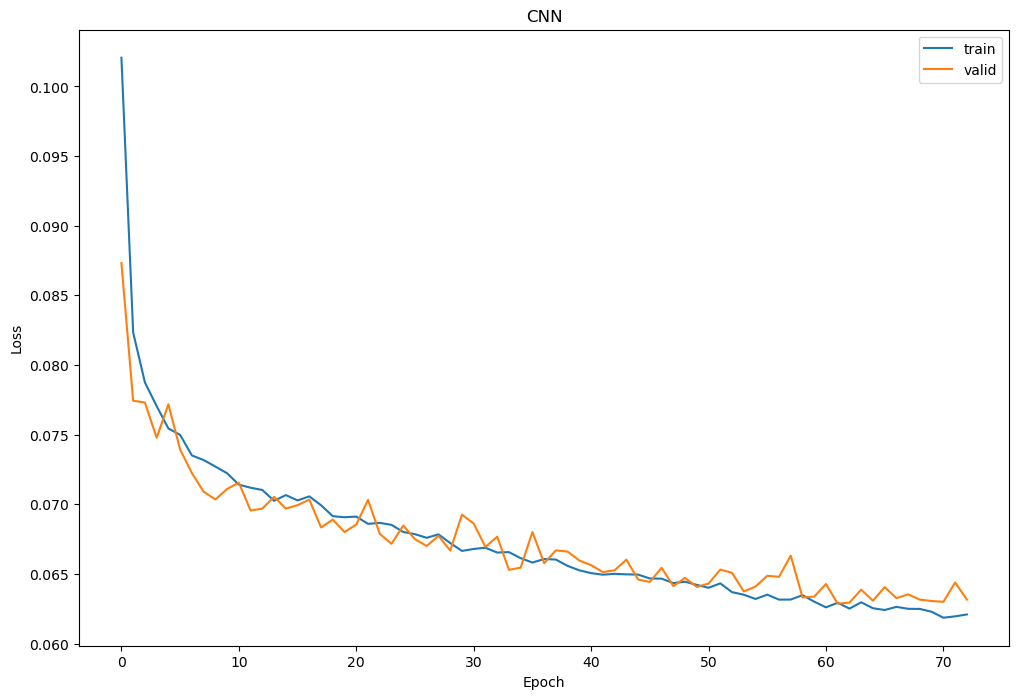

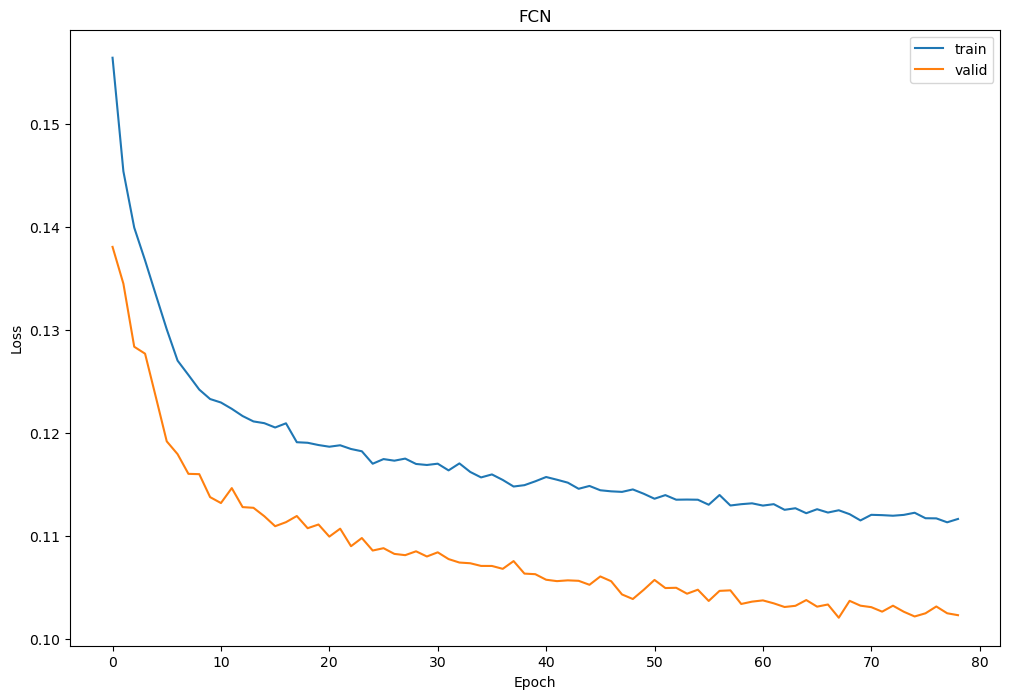

In [31]:
def plot_losses(train_losses, valid_losses, title):
    plt.figure(figsize=(12,8))
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.plot(train_losses)
    plt.plot(valid_losses)
    plt.legend(['train', 'valid'])
    plt.show()

plot_losses(train_losses_cnn, valid_losses_cnn, 'CNN')
plot_losses(train_losses_fcn, valid_losses_fcn, 'FCN')

## **6.2 Running Inference on the Image Colorization Models**

In [32]:
best_model_cnn = ColorizationCNN().to(device)
best_model_cnn.load_state_dict(torch.load('best_model_cnn.pth'))
best_model_fcn = ColorizationLinear().to(device)
best_model_fcn.load_state_dict(torch.load('best_model_fcn.pth'))

def test_model(model, dataloader):
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X, Y in dataloader:
            X, Y = X.to(device), Y.to(device)
            prediction = model(X)
            loss = loss_fn(prediction, Y)
            test_loss += loss.item()

    test_loss /= len(dataloader)
    return test_loss

test_loss_cnn = test_model(best_model_cnn, testloader)
print(f'CNN Test Loss: {test_loss_cnn:.4f}')
test_loss_fcn = test_model(best_model_fcn, testloader)
print(f'FCN Test Loss: {test_loss_fcn:.4f}')

/var/folders/9q/8r66wmfn6xv1yt1q0361mf2r0000gn/T/ipykernel_76907/677238593.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model_cnn.load_state_dict(torch.load('bes

CNN Test Loss: 0.0816
FCN Test Loss: 0.1303


## **7 Comparing Test Results**

/var/folders/9q/8r66wmfn6xv1yt1q0361mf2r0000gn/T/ipykernel_76907/3491304342.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model_cnn.load_state_dict(torch.load('be

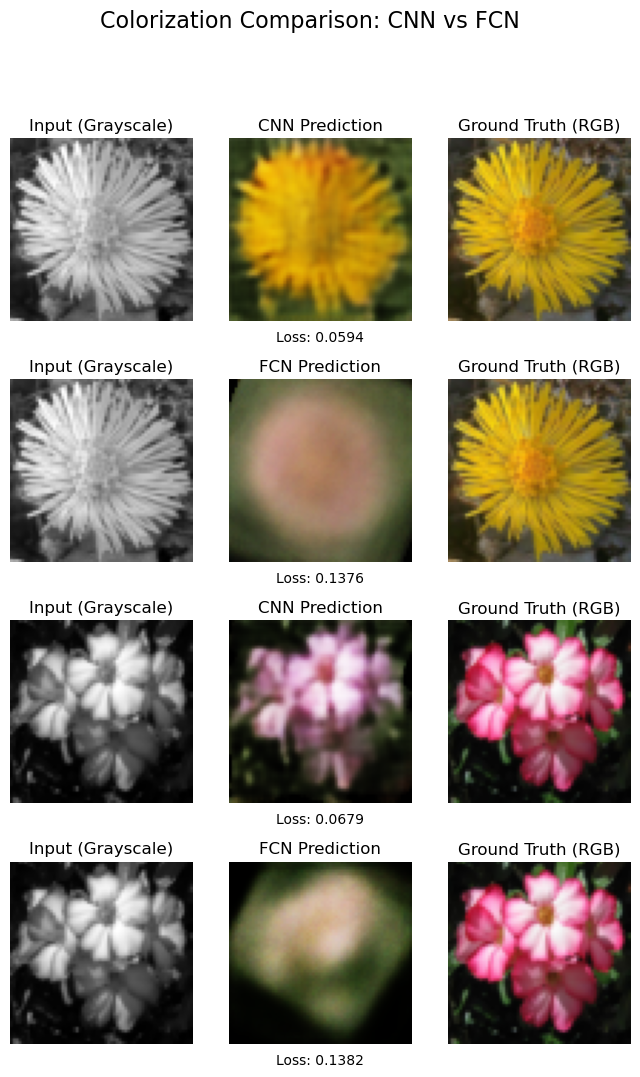

In [33]:
best_model_cnn = ColorizationCNN().to(device)
best_model_cnn.load_state_dict(torch.load('best_model_cnn.pth'))
best_model_fcn = ColorizationLinear().to(device)
best_model_fcn.load_state_dict(torch.load('best_model_fcn.pth'))

def plot_predictions(model_cnn, model_fcn, dataloader, loss_fn, device, batch_indices=[0, 1], img_indices=[0, -1]):
    model_cnn.eval()
    model_fcn.eval()

    all_batches = list(dataloader)
    gray_imgs, rgb_imgs = [], []
    for b_idx, i_idx in zip(batch_indices, img_indices):
        X, Y = all_batches[b_idx]
        X, Y = X.to(device), Y.to(device)
        gray_imgs.append(X[i_idx])
        rgb_imgs.append(Y[i_idx])

    gray_imgs = torch.stack(gray_imgs)
    rgb_imgs = torch.stack(rgb_imgs)

    with torch.no_grad():
        preds_cnn = model_cnn(gray_imgs)
        preds_fcn = model_fcn(gray_imgs)

        losses_cnn = [loss_fn(preds_cnn[i].unsqueeze(0), rgb_imgs[i].unsqueeze(0)).item() for i in range(2)]
        losses_fcn = [loss_fn(preds_fcn[i].unsqueeze(0), rgb_imgs[i].unsqueeze(0)).item() for i in range(2)]

    fig, axes = plt.subplots(4, 3, figsize=(8, 12))
    fig.suptitle('Colorization Comparison: CNN vs FCN', fontsize=16)

    for i in range(2):
        cnn, fcn = i*2, i*2+1

        gray_img = gray_imgs[i].squeeze(0).cpu().numpy()
        axes[cnn,0].imshow(gray_img, cmap='gray')
        axes[fcn,0].imshow(gray_img, cmap='gray')
        axes[cnn,0].set_title('Input (Grayscale)')
        axes[fcn,0].set_title('Input (Grayscale)')

        pred_cnn_img = preds_cnn[i].permute(1,2,0).cpu().numpy().clip(0,1)
        axes[cnn,1].imshow(pred_cnn_img)
        axes[cnn,1].set_title('CNN Prediction')
        axes[cnn,1].text(0.5, -0.05, f'Loss: {losses_cnn[i]:.4f}', ha='center', va='top', transform=axes[cnn,1].transAxes)

        pred_fcn_img = preds_fcn[i].permute(1,2,0).cpu().numpy().clip(0,1)
        axes[fcn,1].imshow(pred_fcn_img)
        axes[fcn,1].set_title('FCN Prediction')
        axes[fcn,1].text(0.5, -0.05, f'Loss: {losses_fcn[i]:.4f}', ha='center', va='top', transform=axes[fcn,1].transAxes)

        rgb_img = rgb_imgs[i].permute(1,2,0).cpu().numpy()
        axes[cnn,2].imshow(rgb_img)
        axes[cnn,2].set_title('Ground Truth (RGB)')
        axes[fcn,2].imshow(rgb_img)
        axes[fcn,2].set_title('Ground Truth (RGB)')

    for ax in axes.flatten():
        ax.axis('off')

    plt.show()

plot_predictions(best_model_cnn, best_model_fcn, testloader, loss_fn, device, batch_indices=[7, -12], img_indices=[6, 9])

## **8.1 Visualizing Feature Maps in the Convolutional Neural Network**

/var/folders/9q/8r66wmfn6xv1yt1q0361mf2r0000gn/T/ipykernel_76907/2524872223.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model_cnn.load_state_dict(torch.load('be

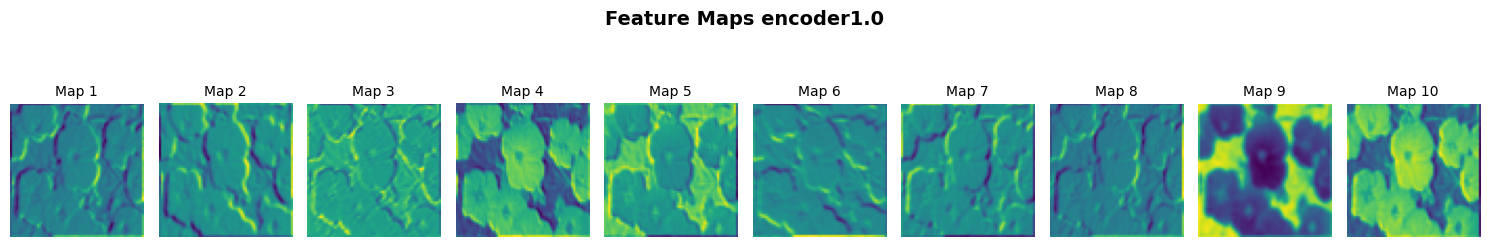

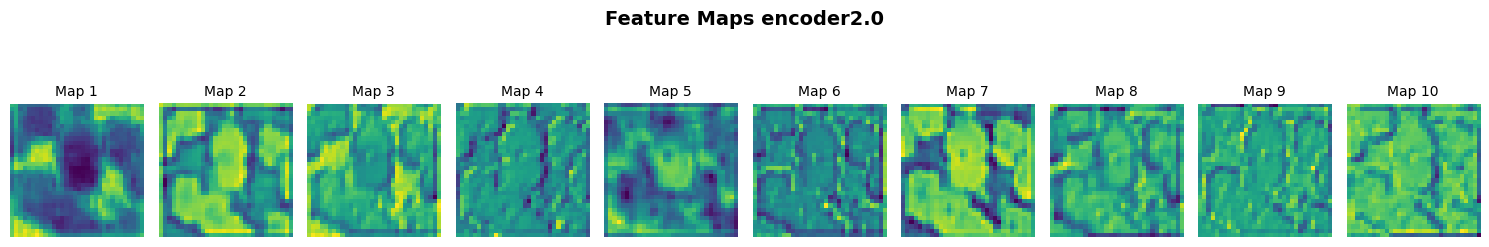

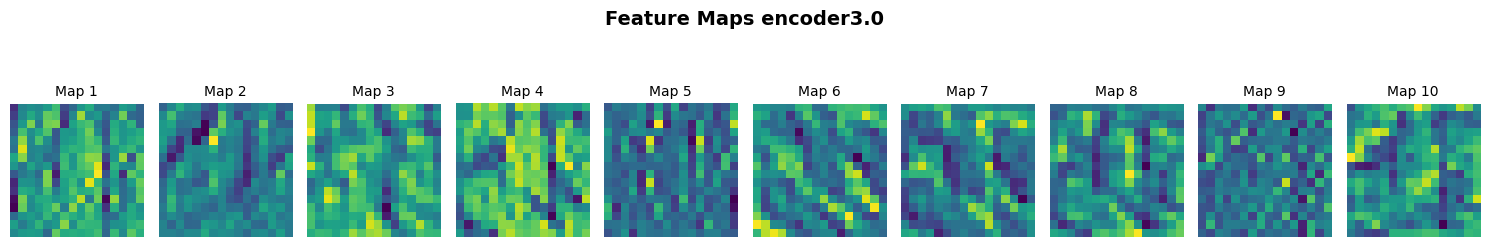

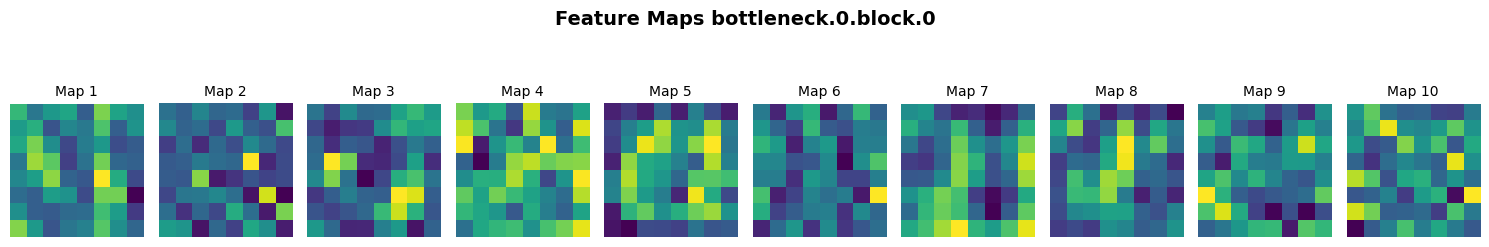

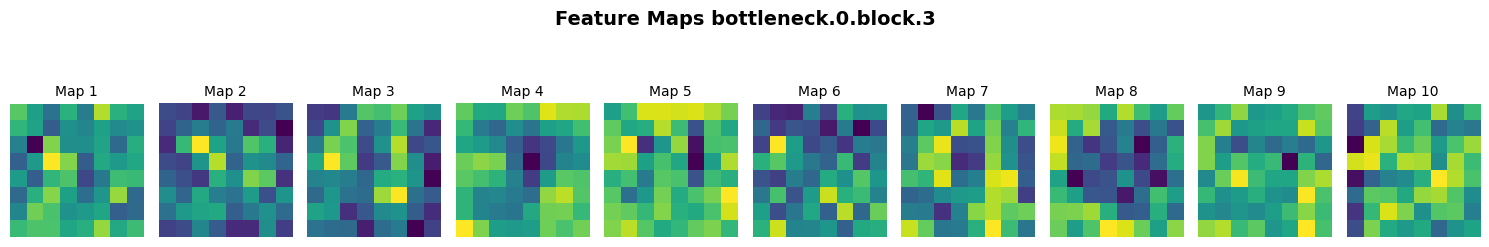

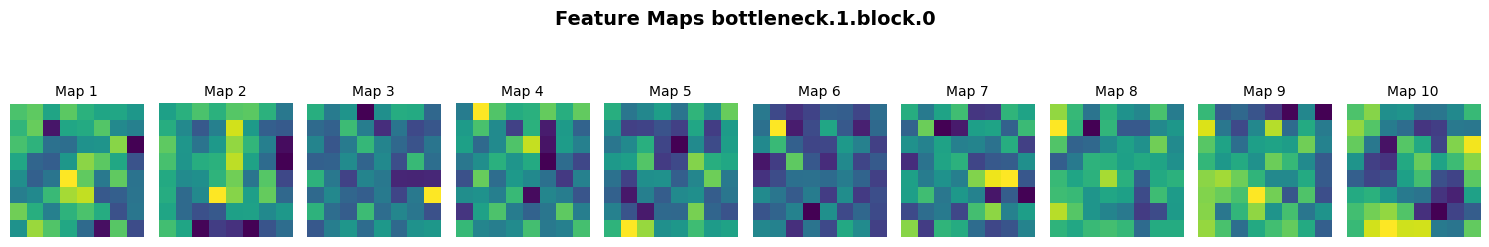

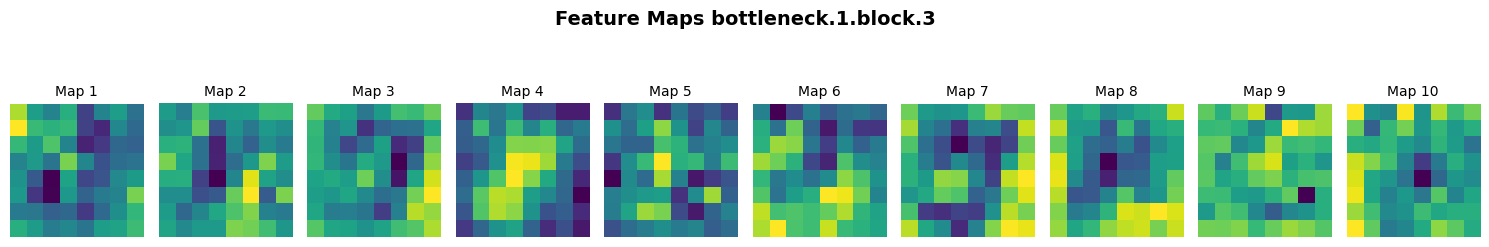

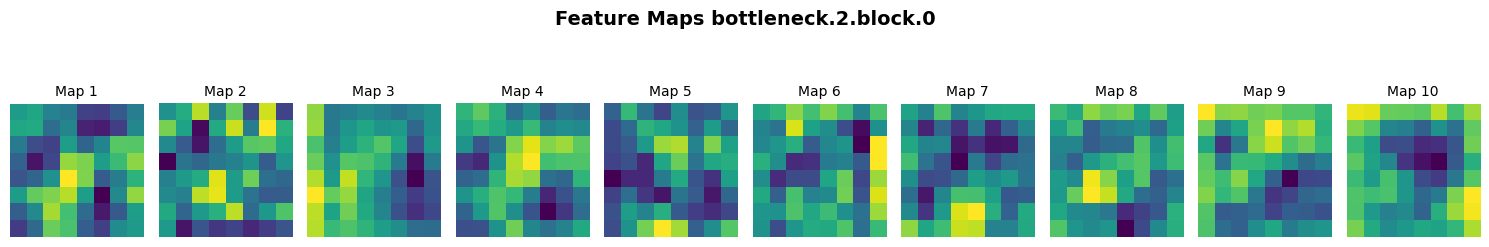

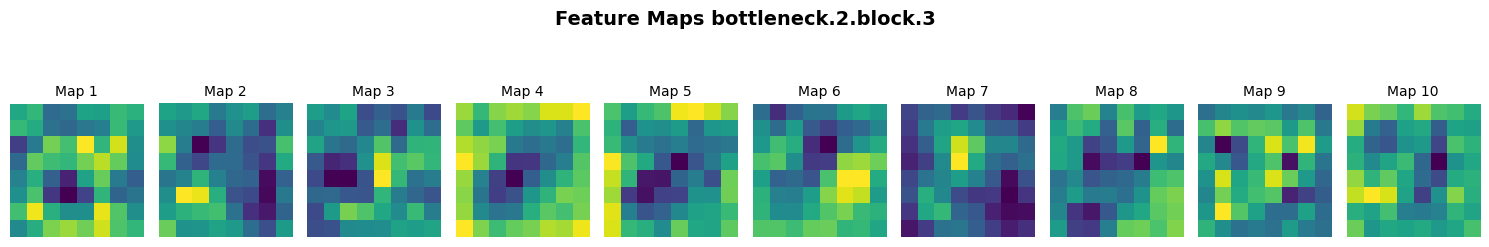

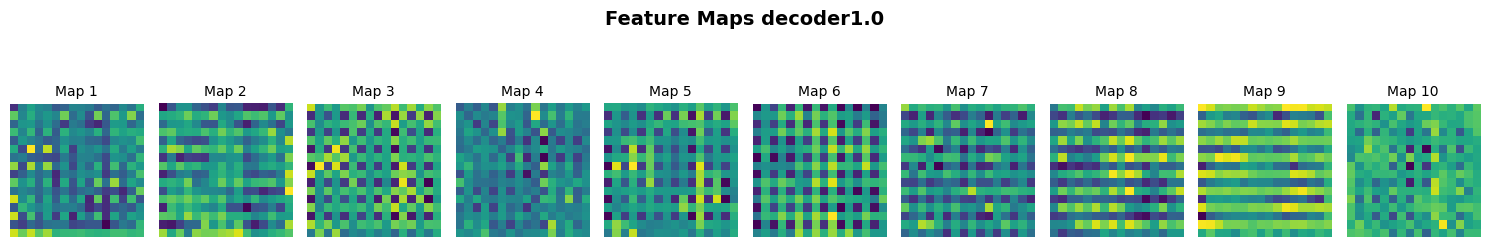

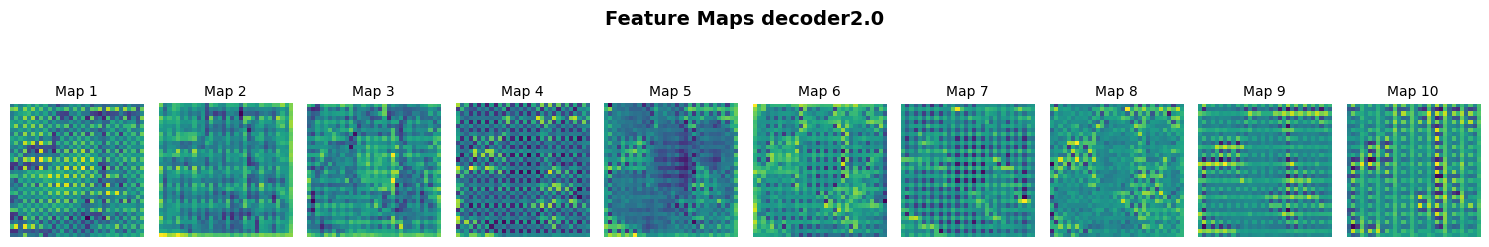

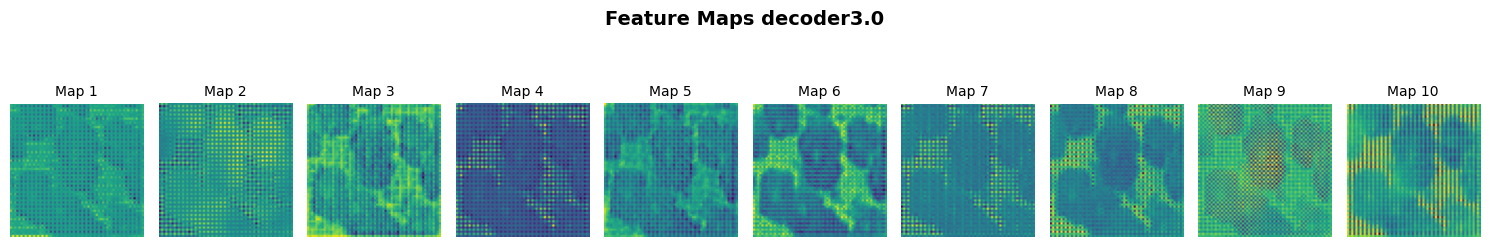

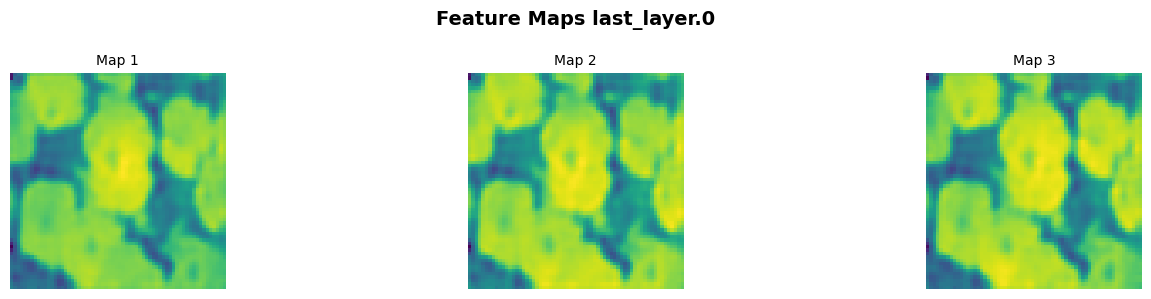

In [34]:
best_model_cnn = ColorizationCNN().to(device)
best_model_cnn.load_state_dict(torch.load('best_model_cnn.pth'))
best_model_cnn.eval()

feature_list = []
hook_handles = []
module_names = []

def hook(module, input, output):
    feature_list.append(output.detach().cpu())

for name, module in best_model_cnn.named_modules():
    if isinstance(module, torch.nn.Conv2d) or isinstance(module, torch.nn.ConvTranspose2d):
        hook_handles.append(module.register_forward_hook(hook))
        module_names.append(name)

with torch.no_grad():
    for X, Y in testloader:
        X, Y = X.to(device), Y.to(device)
        _ = best_model_cnn(X[0].unsqueeze(0))
        break

for layer_name, fmap in zip(module_names, feature_list):
    num_channels = fmap.shape[1]
    num_maps = min(num_channels, 10)
        
    fig, axes = plt.subplots(1, num_maps, figsize=(15, 3))
    fig.suptitle(f'Feature Maps {layer_name}', fontsize=14, fontweight='bold')
    
    if num_maps == 1:
        axes = [axes]
    
    for i in range(num_maps):
        axes[i].imshow(fmap[0, i, :, :], cmap='viridis')
        axes[i].set_title(f'Map {i+1}', fontsize=10)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

for handle in hook_handles:
    handle.remove()

## **8.2 Visualizing Weights in the Fully Connected Network**

/var/folders/9q/8r66wmfn6xv1yt1q0361mf2r0000gn/T/ipykernel_76907/3360460769.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model_fcn.load_state_dict(torch.load('be

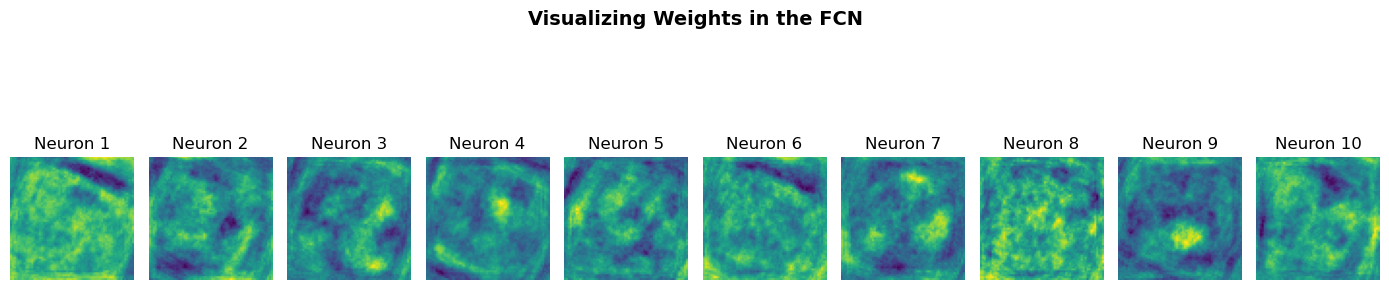

In [35]:
best_model_fcn = ColorizationLinear().to(device)
best_model_fcn.load_state_dict(torch.load('best_model_fcn.pth'))
best_model_fcn.eval()

fc1_weights = best_model_fcn.layer1[0].weight.data.cpu()

num_neurons = 10
offset = 67
step = 15
selected_weights = fc1_weights[offset:offset+step*num_neurons:step]

plt.figure(figsize=(14, 4))
for i, weights in enumerate(selected_weights):
    plt.subplot(1, num_neurons, i + 1)
    plt.imshow(weights.reshape(64, 64), cmap='viridis')
    plt.title(f'Neuron {i+1}')
    plt.axis('off')
plt.suptitle('Visualizing Weights in the FCN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()